In [11]:
import ImtaTURB as imta

In [12]:
file_p = "Datos/OpenFOAM/20_cm/p"
file_U = "Datos/OpenFOAM/20_cm/U"
file_nut = "Datos/OpenFOAM/20_cm/nut"

In [13]:
# Cargar p, U y nut
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)
U_probes, tiempo_U, coords_U, fs_U = imta.cargar_U_OpenFOAM(file_U)
nut_probes, tiempo_nut, coords_nut, fs_nut = imta.cargar_nut_OpenFOAM(file_nut)
# Ventana de tiempo
inicio = 50 # Ignorando arranque en caliente
# Probe a analizar
probe_1 = 0

c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)
Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


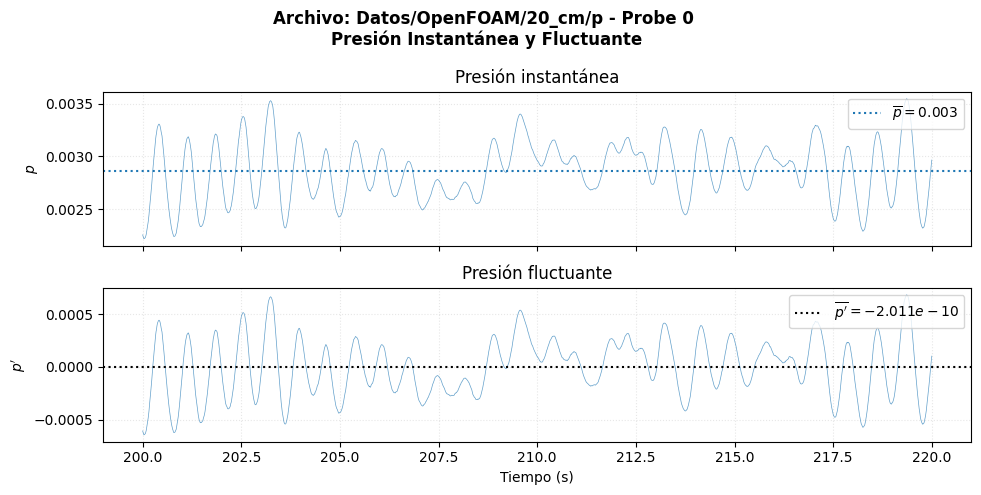

In [14]:
# Proceso de presión
p1, t1, _ = imta.recortar_tiempo(p_probes, probe=probe_1, inicio=inicio)
p1_fluc, _ = imta.fluctuante(p1, tiempo=t1)

imta.plot_p(t1, p1_fluc,
            titulo=f'Archivo: {file_p} - Probe {probe_1} \nPresión Instantánea y Fluctuante',
            etiqueta='p');

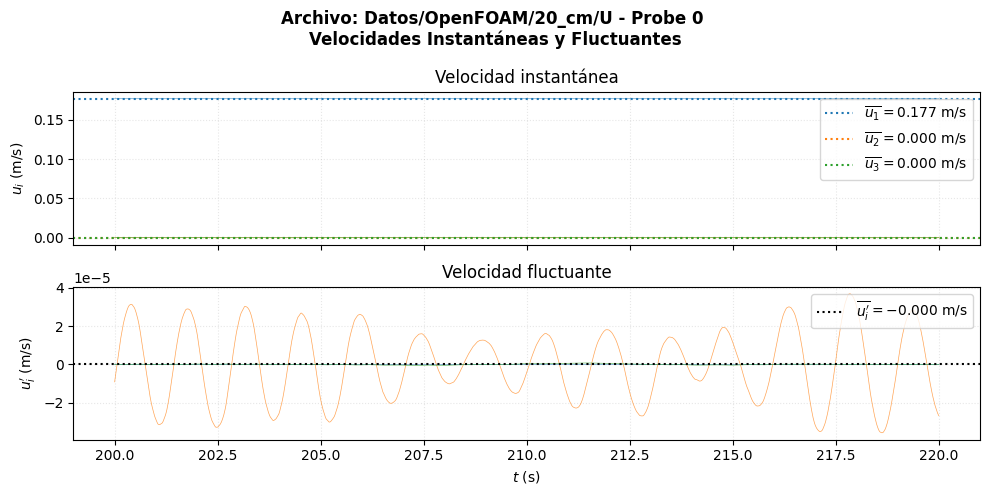

In [15]:
# Proceso de velocidad
u1_a, u2_a, u3_a, tU_a, dfU_a = imta.recortar_tiempo(U_probes, probe=probe_1, inicio=inicio)
u1_fluc, _ = imta.fluctuante(u1_a, tiempo=tU_a)
u2_fluc, _ = imta.fluctuante(u2_a, tiempo=tU_a)
u3_fluc, _ = imta.fluctuante(u3_a, tiempo=tU_a)

imta.plot_ui(tU_a, u1_fluc, u2_fluc, u3_fluc,
            titulo=f'Archivo: {file_U} - Probe {probe_1} \nVelocidades Instantáneas y Fluctuantes',
            etiquetas=('u_1', 'u_2', 'u_3'));

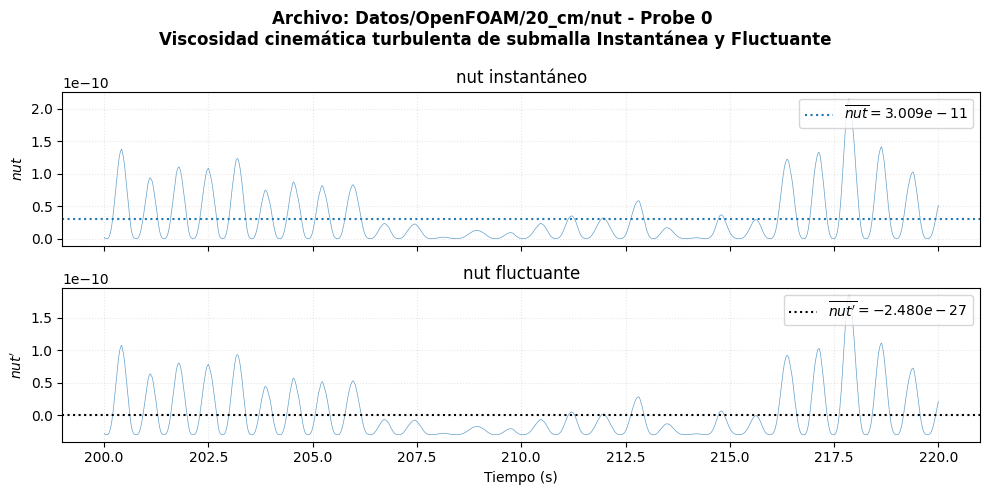

In [16]:
# Proceso de viscosidad cinemática turbulenta de submalla
nut, t_nut, _ = imta.recortar_tiempo(nut_probes, probe=probe_1, inicio=inicio)
nut_fluc, _ = imta.fluctuante(nut, tiempo=t_nut)
imta.plot_nut(t_nut, nut_fluc,
            titulo=f'Archivo: {file_nut} - Probe {probe_1} \nViscosidad cinemática turbulenta de submalla Instantánea y Fluctuante',
            etiqueta='nut');

In [17]:
# Forma de extraer coordenadas según el probe
probe_1 = 130
print(f"Coordenadas probe (p) {probe_1}: {coords_p[probe_1]}")
print(f"Coordenadas probe (U) {probe_1}: {coords_U[probe_1]}")
print(f"Coordenadas probe (nut) {probe_1}: {coords_nut[probe_1]}")

Coordenadas probe (p) 130: (0.62462, 0.1, 0.29566)
Coordenadas probe (U) 130: (0.62462, 0.1, 0.29566)
Coordenadas probe (nut) 130: (0.62462, 0.1, 0.29566)


c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


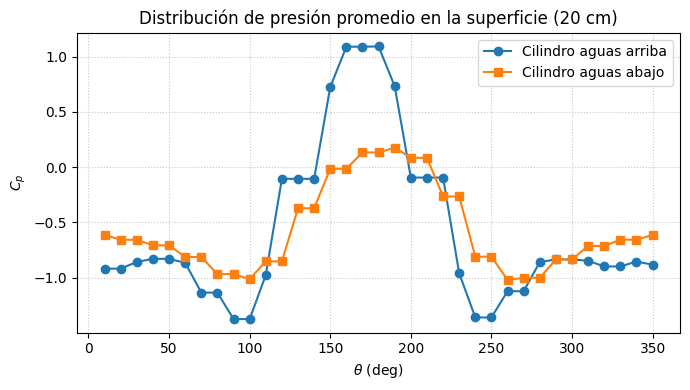

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import ImtaTURB as imta

# === Datos del caso ===
rho = 1000.0            # kg/m^3
U_inf = 0.177           # m/s
D = 0.05                # m
R = D / 2               # m
span = 0.26             # m (altura de la pila)

# Probes alrededor de cada cilindro
# Aguas arriba: 10° en probe 25, 360° en 59 (cada 10°)
up_ini = 25
up_fin = 59

# Aguas abajo: 10° en probe 96, 360° en 130 (cada 10°)
down_ini = 96
down_fin = 130

# Ángulos (10 a 350)
angulos_deg = np.arange(10, 360, 10)
angulos_rad = np.radians(angulos_deg)
dtheta = np.radians(10.0)

# === Cargar presión ===
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)

# === Función auxiliar: Cp promedio vs theta ===
def cp_promedio_por_theta(p_probes, probes_ordenados, rho, U_inf, t_ini=None):
    series_p = []
    for prb in probes_ordenados:
        p_i, t_i, _ = imta.recortar_tiempo(
            p_probes, probe=prb,
            inicio=tiempo_p.iloc[0] if t_ini is None else t_ini
        )
        series_p.append(p_i.values)

    p_theta = np.vstack(series_p).T  # (n_tiempos, n_angulos)
    p_pa = rho * p_theta             # convertir a Pa (p en m^2/s^2)

    # Promedio temporal por ángulo
    p_mean = np.mean(p_pa, axis=0)

    # Cp = p / (0.5*rho*U_inf^2) (sin p_inf)
    q = 0.5 * rho * U_inf**2
    Cp = p_mean / q

    return Cp, p_pa

# === Cp para cilindro aguas arriba ===
probes_up = list(range(up_ini, up_fin + 1))
Cp_up, p_pa_up = cp_promedio_por_theta(p_probes, probes_up, rho, U_inf)

# === Cp para cilindro aguas abajo ===
probes_down = list(range(down_ini, down_fin + 1))
Cp_down, p_pa_down = cp_promedio_por_theta(p_probes, probes_down, rho, U_inf)

# === Gráfica Cp vs theta ===
plt.figure(figsize=(7, 4))
plt.plot(angulos_deg, Cp_up, 'o-', label='Cilindro aguas arriba')
plt.plot(angulos_deg, Cp_down, 's-', label='Cilindro aguas abajo')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$C_p$')
plt.title('Distribución de presión promedio en la superficie (20 cm)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()

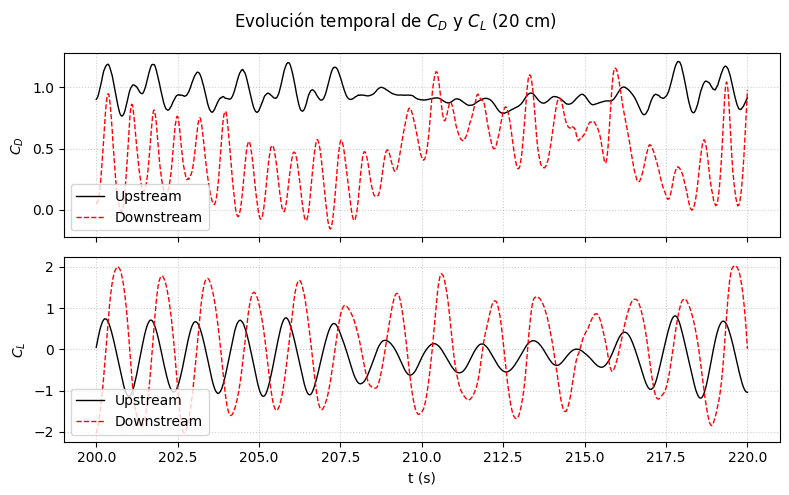

In [19]:
# === Extraer presión por cilindro ===
def extraer_p_theta(p_probes, probes_ordenados, t_inicio=200.0):
    series_p = []
    for prb in probes_ordenados:
        p_i, t_i, _ = imta.recortar_tiempo(
            p_probes, probe=prb,
            inicio=t_inicio
        )
        series_p.append(p_i.values)

    p_theta = np.vstack(series_p).T  # (n_tiempos, n_angulos)
    return p_theta, t_i.values

p_theta_up, tiempo = extraer_p_theta(p_probes, list(range(up_ini, up_fin + 1)), t_inicio=200.0)
p_theta_dn, _ = extraer_p_theta(p_probes, list(range(down_ini, down_fin + 1)), t_inicio=200.0)

# === Función para CD y CL ===
def cd_cl_from_p(p_theta, theta, rho, U_inf, R, D, span):
    p_pa = rho * p_theta
    nx = np.cos(theta)
    nz = np.sin(theta)

    Fx = -np.sum(p_pa * nx, axis=1) * R * dtheta  # N/m
    Fz = -np.sum(p_pa * nz, axis=1) * R * dtheta  # N/m

    Fx_total = Fx * span
    Fz_total = Fz * span

    A = D * span
    q = 0.5 * rho * U_inf**2
    CD = Fx_total / (q * A)
    CL = Fz_total / (q * A)

    return CD, CL

CD_up, CL_up = cd_cl_from_p(p_theta_up, angulos_rad, rho, U_inf, R, D, span)
CD_dn, CL_dn = cd_cl_from_p(p_theta_dn, angulos_rad, rho, U_inf, R, D, span)

# === Gráficas ===
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

ax[0].plot(tiempo, CD_up, 'k-', linewidth=1, label='Upstream')
ax[0].plot(tiempo, CD_dn, 'r--', linewidth=1, label='Downstream')
ax[0].set_ylabel(r'$C_D$')
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(loc='lower left')
#ax[0].set_xlim([100,105])

ax[1].plot(tiempo, CL_up, 'k-', linewidth=1, label='Upstream')
ax[1].plot(tiempo, CL_dn, 'r--', linewidth=1, label='Downstream')
ax[1].set_ylabel(r'$C_L$')
ax[1].set_xlabel('t (s)')
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(loc='lower left')

plt.suptitle('Evolución temporal de $C_D$ y $C_L$ (20 cm)')
plt.tight_layout()